# 03_resistance_surface.ipynb

Build species-specific resistance surfaces for ecological connectivity modeling.

## Goal
Convert environmental layers + habitat data into raster resistance surfaces usable in Omniscape / circuit-based connectivity models.

## Inputs
- Clean GBIF occurrences (GeoPackage)
- Natura 2000 / study area layers
- Optional land cover raster (to be added later)

## Outputs
- species resistance GeoTIFF (EPSG:3035, float32)
- resistance preview plots
- QGIS-ready raster layers


## Imports

In [1]:
from pathlib import Path

import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds

import matplotlib.pyplot as plt


## Paths

In [2]:
PROJECT_ROOT = Path.cwd().parent

SPECIES = 'Emys_orbicularis'  # change per run

SPECIES_GPKG = PROJECT_ROOT / 'data' / 'processed' / 'species' / SPECIES / f'{SPECIES}.gpkg'

OUTPUT_DIR = PROJECT_ROOT / 'data' / 'processed' / 'resistance'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_RASTER = OUTPUT_DIR / f'{SPECIES}_resistance.tif'

print(SPECIES_GPKG)


/home/linda/Documents/myData/data-management/data/processed/species/Emys_orbicularis/Emys_orbicularis.gpkg


## Load Species Occurrences

In [3]:
gdf = gpd.read_file(SPECIES_GPKG)

# Ensure correct CRS for modeling
gdf = gdf.to_crs('EPSG:3035')

gdf.head()


,gbifID,species,decimalLatitude,decimalLongitude,countryCode,eventDate,basisOfRecord,coordinateUncertaintyInMeters,year,month,day,geometry
0,6183525431,Emys orbicularis,37.034090,-7.812064,PT,2026-01-24,HUMAN_OBSERVATION,15.0,2026,1.0,24.0,POINT (2739144.692 1736198.277)
1,6182939655,Emys orbicularis,37.765770,-8.005957,PT,2026-02-23,HUMAN_OBSERVATION,3.0,2026,2.0,23.0,POINT (2739131.699 1819316.706)
2,6182844310,Emys orbicularis,37.032825,-7.812135,PT,2025-05-08,HUMAN_OBSERVATION,32.0,2025,5.0,8.0,POINT (2739109.836 1736063.004)
3,6170564886,Emys orbicularis,37.765718,-8.006792,PT,2026-02-23,HUMAN_OBSERVATION,5.0,2026,2.0,23.0,POINT (2739058.674 1819328.418)
4,6169208199,Emys orbicularis,37.028742,-8.009981,PT,2026-02-27,HUMAN_OBSERVATION,19.0,2026,2.0,27.0,POINT (2721809.008 1739739.964)


## Define Study Area Bounds

In [4]:
# Bounding box from occurrences (can later be replaced by Natura2000 extent)
minx, miny, maxx, maxy = gdf.total_bounds

# Optional buffer (meters)
buffer = 20000

minx -= buffer
miny -= buffer
maxx += buffer
maxy += buffer

print(minx, miny, maxx, maxy)


2629412.19939539 1713863.985277782 2921853.445363991 2256918.7408887744


## Define Raster Grid

In [5]:
# Resolution (meters per pixel)
resolution = 1000  # adjust later (100–1000m typical)

width = int((maxx - minx) / resolution)
height = int((maxy - miny) / resolution)

transform = from_bounds(minx, miny, maxx, maxy, width, height)

print('Raster size:', width, height)


Raster size: 292 543


## Create Simple Resistance Model

This is a baseline placeholder model:
- occurrences = low resistance zones
- background = high resistance


In [6]:
# Base resistance surface (start with uniform resistance)
resistance = np.ones((height, width), dtype=np.float32) * 100

print(resistance.shape)


(543, 292)


## Rasterize Occurrences (Habitat Attraction Layer)

In [7]:
shapes = ((geom, 1) for geom in gdf.geometry)

occurrence_raster = rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype=np.uint8
)

print(occurrence_raster.sum())


37


## Convert Occurrences to Resistance Modifier

In [8]:
# Lower resistance where species occurs
resistance[occurrence_raster == 1] = 1

# Optional smoothing effect (simple neighborhood influence)
from scipy.ndimage import gaussian_filter

resistance = gaussian_filter(resistance, sigma=2)

print('Resistance computed')


Resistance computed


## Visualize Resistance Surface

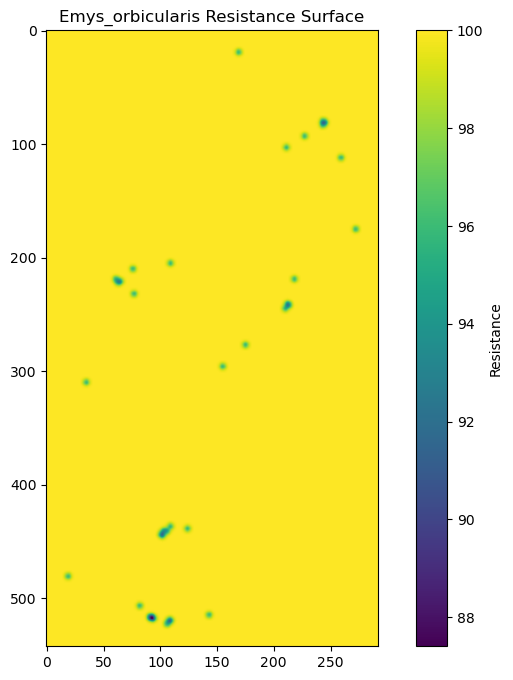

In [9]:
plt.figure(figsize=(10, 8))
plt.imshow(resistance, cmap='viridis')
plt.colorbar(label='Resistance')
plt.title(f'{SPECIES} Resistance Surface')
plt.show()


## Export GeoTIFF (QGIS + Omniscape Ready)

In [10]:
with rasterio.open(
    OUTPUT_RASTER,
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=1,
    dtype=np.float32,
    crs='EPSG:3035',
    transform=transform,
    compress='lzw'
) as dst:
    dst.write(resistance.astype(np.float32), 1)

print('Saved:', OUTPUT_RASTER)


Saved: /home/linda/Documents/myData/data-management/data/processed/resistance/Emys_orbicularis_resistance.tif


## Summary

In [11]:
print('--- RESISTANCE SURFACE COMPLETE ---')
print('Species:', SPECIES)
print('Output:', OUTPUT_RASTER)
print('CRS: EPSG:3035')
print('Resolution:', resolution, 'm')


--- RESISTANCE SURFACE COMPLETE ---
Species: Emys_orbicularis
Output: /home/linda/Documents/myData/data-management/data/processed/resistance/Emys_orbicularis_resistance.tif
CRS: EPSG:3035
Resolution: 1000 m
